# COVID-19 Clinical Data — Phase 1
## Data Loading, Exploratory Data Analysis, Visualization & Problem Formulation

**Course:** Machine Learning 2026 — COVID-19 Dataset Prediction Project
**Dataset:** Mexico COVID-19 Clinical Data (Government of Mexico, *SISVER* / Dirección General de Epidemiología)

This notebook covers **Section A** of the project (*Problem Formulation and Dataset Analysis*): it loads the data, characterises it, surfaces the data-quality and sampling issues that the surveillance design introduces, and ends with three concrete, leakage-aware prediction tasks you can choose from for Sections B and C.

**Design note.** Public mirrors of this dataset differ in their exact column names (raw Spanish names such as `SEXO`, `EDAD`, `TIPO_PACIENTE`, `FECHA_DEF`, `UCI`; older exports use `RESULTADO` instead of `CLASIFICACION_FINAL`; some English-renamed mirrors exist). To stay reproducible across snapshots, every analysis below resolves columns through an **alias map** and *skips gracefully* (with a printed note) when a column is absent, rather than crashing. Adapt the alias map in one place if your download differs.

In [18]:
# ---------------------------------------------------------------------------
# 0. Environment & reproducibility
# ---------------------------------------------------------------------------
import sys, os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    HAVE_SNS = True
except Exception:
    HAVE_SNS = False
    plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else plt.style.use("default")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("seaborn     :", ("available" if HAVE_SNS else "NOT installed (matplotlib fallback used)"))
print("random seed :", RANDOM_SEED)

Python      : 3.10.20
pandas      : 2.3.3
numpy       : 2.2.6
seaborn     : available
random seed : 42


## 1. Download the dataset

We use `kagglehub` exactly as specified in the task. The first run downloads and caches the files; later runs reuse the cache. If `kagglehub` is missing, install it with `pip install kagglehub` (Kaggle authentication may be required in your environment).

In [19]:
# ---------------------------------------------------------------------------
# 1. Download (exact snippet required by the task)
# ---------------------------------------------------------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marianarfranklin/mexico-covid19-clinical-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Simon\.cache\kagglehub\datasets\marianarfranklin\mexico-covid19-clinical-data\versions\3


## 2. Load into a DataFrame (robust to file layout & encoding)

`kagglehub` returns a *directory*. We locate the CSV(s) inside it, pick the largest one (the main line-list), and try UTF-8 first, falling back to Latin-1 — Mexican government CSVs are frequently Latin-1 encoded.

In [20]:
# ---------------------------------------------------------------------------
# 2. Locate and load the main CSV
# ---------------------------------------------------------------------------
def list_data_files(root):
    exts = ("*.csv", "*.CSV", "*.tsv", "*.txt")
    files = []
    for e in exts:
        files += glob.glob(os.path.join(root, "**", e), recursive=True)
    return sorted(files, key=lambda f: os.path.getsize(f), reverse=True)

candidates = list_data_files(path)
print("Tabular files found:")
for f in candidates:
    print(f"  {os.path.getsize(f)/1e6:8.2f} MB  {f}")

assert candidates, f"No CSV/TSV files found under {path!r}. Inspect the folder manually."
DATA_FILE = candidates[0]
print("\nUsing:", DATA_FILE)

def robust_read_csv(fp):
    seps = [",", ";", "\t"]
    encodings = ["utf-8", "latin-1"]
    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                df_try = pd.read_csv(fp, sep=sep, encoding=enc, low_memory=False)
                # A correct parse yields more than one column.
                if df_try.shape[1] > 1:
                    print(f"Parsed with encoding={enc!r}, sep={sep!r}")
                    return df_try
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Could not parse {fp}: {last_err}")

df = robust_read_csv(DATA_FILE)
print("Loaded shape:", df.shape)

Tabular files found:
     48.06 MB  C:\Users\Simon\.cache\kagglehub\datasets\marianarfranklin\mexico-covid19-clinical-data\versions\3\mexico_covid19.csv
     48.06 MB  C:\Users\Simon\.cache\kagglehub\datasets\marianarfranklin\mexico-covid19-clinical-data\versions\3\mexico_covid19.csv

Using: C:\Users\Simon\.cache\kagglehub\datasets\marianarfranklin\mexico-covid19-clinical-data\versions\3\mexico_covid19.csv
Parsed with encoding='utf-8', sep=','
Loaded shape: (263007, 41)


## 3. First look: shape, dtypes, sample rows

Before any cleaning we record the raw shape and the raw column inventory. This is the ground truth we audit everything else against.

In [21]:
# ---------------------------------------------------------------------------
# 3. Raw overview
# ---------------------------------------------------------------------------
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}\n")
print("Raw columns:")
print(list(df.columns))

display(df.head())
display(df.dtypes.to_frame("dtype"))

Rows: 263,007   Columns: 41

Raw columns:
['id', 'FECHA_ARCHIVO', 'ID_REGISTRO', 'ENTIDAD_UM', 'ENTIDAD_RES', 'RESULTADO', 'DELAY', 'ENTIDAD_REGISTRO', 'ENTIDAD', 'ABR_ENT', 'FECHA_ACTUALIZACION', 'ORIGEN', 'SECTOR', 'SEXO', 'ENTIDAD_NAC', 'MUNICIPIO_RES', 'TIPO_PACIENTE', 'FECHA_INGRESO', 'FECHA_SINTOMAS', 'FECHA_DEF', 'INTUBADO', 'NEUMONIA', 'EDAD', 'NACIONALIDAD', 'EMBARAZO', 'HABLA_LENGUA_INDIG', 'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO', 'MIGRANTE', 'PAIS_NACIONALIDAD', 'PAIS_ORIGEN', 'UCI']


,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,FECHA_ACTUALIZACION,ORIGEN,SECTOR,SEXO,ENTIDAD_NAC,MUNICIPIO_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,EMBARAZO,HABLA_LENGUA_INDIG,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,2020-04-19,2,12,2,25,13.0,1,2020-03-20,2020-03-12,9999-99-99,97,2,74,1,97,2,1,2,2,2,1,2,2,1,2,2,2,99,MÃ©xico,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,2020-04-19,1,4,1,16,98.0,2,2020-03-30,2020-03-30,9999-99-99,2,2,71,1,2,2,1,1,2,2,1,2,2,1,2,1,99,99,MÃ©xico,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,2020-04-19,1,4,2,8,19.0,2,2020-04-02,2020-03-24,9999-99-99,2,1,50,1,97,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃ©xico,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,2020-04-19,2,4,1,15,33.0,1,2020-04-01,2020-03-26,9999-99-99,97,2,25,1,2,2,2,2,2,2,2,2,2,1,2,2,99,99,MÃ©xico,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,2020-04-19,1,4,1,99,15.0,1,2020-04-07,2020-04-06,9999-99-99,97,2,28,1,2,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃ©xico,97,97


,dtype
id,int64
FECHA_ARCHIVO,object
ID_REGISTRO,object
ENTIDAD_UM,int64
ENTIDAD_RES,int64
RESULTADO,int64
DELAY,int64
ENTIDAD_REGISTRO,int64
ENTIDAD,object
ABR_ENT,object


## 4. Schema resolution (alias map)

The dataset uses raw Spanish field names. We map each *canonical* concept to whatever name is actually present, so the rest of the notebook is snapshot-independent. Columns we cannot find are reported and simply skipped downstream.

Reference encoding (Mexican DGE data dictionary):
- **Binary clinical fields** (`DIABETES`, `NEUMONIA`, ...): `1 = Yes`, `2 = No`, and `97 / 98 / 99 = N/A / unknown / unspecified` → treated as missing.
- **SEXO**: `1 = Female`, `2 = Male`, `99 = unspecified`.
- **TIPO_PACIENTE**: `1 = Outpatient (ambulatory)`, `2 = Hospitalized`.
- **FECHA_DEF**: a real date means the patient died; the placeholder `9999-99-99` means the patient was alive at record time.
- **CLASIFICACION_FINAL**: `1–3 = confirmed COVID-19` (by different routes), `4–7 = negative / inconclusive / pending`. Older exports use `RESULTADO` (`1 = positive`).

In [22]:
# ---------------------------------------------------------------------------
# 4. Resolve columns by alias (case-insensitive)
# ---------------------------------------------------------------------------
def find_col(frame, *aliases):
    norm = {c.upper().strip(): c for c in frame.columns}
    for a in aliases:
        hit = norm.get(a.upper().strip())
        if hit is not None:
            return hit
    return None

# canonical_name -> possible raw names (Spanish first, then English mirrors)
ALIASES = {
    "age":            ["EDAD", "AGE"],
    "sex":            ["SEXO", "SEX"],
    "patient_type":   ["TIPO_PACIENTE", "PATIENT_TYPE"],
    "date_died":      ["FECHA_DEF", "DATE_DIED"],
    "date_admission": ["FECHA_INGRESO", "DATE_ADMISSION"],
    "date_symptoms":  ["FECHA_SINTOMAS", "DATE_SYMPTOMS"],
    "intubed":        ["INTUBADO", "INTUBED"],
    "pneumonia":      ["NEUMONIA", "PNEUMONIA"],
    "icu":            ["UCI", "ICU"],
    "pregnancy":      ["EMBARAZO", "PREGNANT", "PREGNANCY"],
    "diabetes":       ["DIABETES"],
    "copd":           ["EPOC", "COPD"],
    "asthma":         ["ASMA", "ASTHMA"],
    "immsupr":        ["INMUSUPR", "INMSUPR", "IMMSUPR"],
    "hypertension":   ["HIPERTENSION", "HYPERTENSION"],
    "other_disease":  ["OTRA_COM", "OTHER_DISEASE", "OTRAS_COM"],
    "cardiovascular": ["CARDIOVASCULAR"],
    "obesity":        ["OBESIDAD", "OBESITY"],
    "renal_chronic":  ["RENAL_CRONICA", "RENAL_CHRONIC"],
    "tobacco":        ["TABAQUISMO", "TOBACCO"],
    "contact_other":  ["OTRO_CASO", "CONTACT_OTHER_COVID"],
    "classification": ["CLASIFICACION_FINAL", "CLASIFFICATION_FINAL",
                       "CLASSIFICATION_FINAL", "RESULTADO", "RESULTADO_LAB"],
    "usmer":          ["USMER", "ORIGEN"],
    "sector":         ["SECTOR"],
    "medical_unit":   ["ENTIDAD_UM", "MEDICAL_UNIT"],
    "state_res":      ["ENTIDAD_RES", "ENTIDAD_FEDERATIVA"],
}

COL = {canon: find_col(df, *names) for canon, names in ALIASES.items()}

resolved   = {k: v for k, v in COL.items() if v}
unresolved = [k for k, v in COL.items() if not v]
print("Resolved columns:")
for k, v in resolved.items():
    print(f"  {k:14s} -> {v}")
print("\nNot found in this snapshot (analyses using them are skipped):")
print(" ", unresolved if unresolved else "none")

# Comorbidity-style binary fields actually present:
COMORBID_KEYS = ["diabetes", "copd", "asthma", "immsupr", "hypertension",
                 "other_disease", "cardiovascular", "obesity",
                 "renal_chronic", "tobacco", "pneumonia"]
COMORBID_KEYS = [k for k in COMORBID_KEYS if COL[k]]
print("\nBinary clinical fields available:", COMORBID_KEYS)

Resolved columns:
  age            -> EDAD
  sex            -> SEXO
  patient_type   -> TIPO_PACIENTE
  date_died      -> FECHA_DEF
  date_admission -> FECHA_INGRESO
  date_symptoms  -> FECHA_SINTOMAS
  intubed        -> INTUBADO
  pneumonia      -> NEUMONIA
  icu            -> UCI
  pregnancy      -> EMBARAZO
  diabetes       -> DIABETES
  copd           -> EPOC
  asthma         -> ASMA
  immsupr        -> INMUSUPR
  hypertension   -> HIPERTENSION
  other_disease  -> OTRA_COM
  cardiovascular -> CARDIOVASCULAR
  obesity        -> OBESIDAD
  renal_chronic  -> RENAL_CRONICA
  tobacco        -> TABAQUISMO
  contact_other  -> OTRO_CASO
  classification -> RESULTADO
  usmer          -> ORIGEN
  sector         -> SECTOR
  medical_unit   -> ENTIDAD_UM
  state_res      -> ENTIDAD_RES

Not found in this snapshot (analyses using them are skipped):
  none

Binary clinical fields available: ['diabetes', 'copd', 'asthma', 'immsupr', 'hypertension', 'other_disease', 'cardiovascular', 'obesity', 're

## 5. Cleaning & derived variables

We do **not** overwrite the raw frame. We build a tidy working frame `data` with decoded, analysis-ready columns:

- `AGE` — numeric, implausible values (<0 or >120) set to NaN.
- `SEX_LABEL` — Female / Male (99 → NaN).
- `HOSPITALIZED` — 1 if hospitalized, 0 if outpatient.
- `DIED` — 1 if `FECHA_DEF` is a real date, else 0.
- `COVID_POS` — 1 if `CLASIFICACION_FINAL` ∈ {1,2,3} (or `RESULTADO == 1`).
- Each available binary clinical field → `{1, 0, NaN}` (97/98/99 → NaN).

In [23]:
# ---------------------------------------------------------------------------
# 5. Decode into a clean working frame
# ---------------------------------------------------------------------------
MISSING_CODES = {97, 98, 99, "97", "98", "99"}

def decode_binary(s):
    """1 -> 1 (yes), 2 -> 0 (no), 97/98/99 -> NaN."""
    out = pd.to_numeric(s, errors="coerce")
    out = out.where(~out.isin([97, 98, 99]))
    return out.map({1: 1, 2: 0})

data = pd.DataFrame(index=df.index)

# Age
if COL["age"]:
    age = pd.to_numeric(df[COL["age"]], errors="coerce")
    data["AGE"] = age.where((age >= 0) & (age <= 120))

# Sex
if COL["sex"]:
    sx = pd.to_numeric(df[COL["sex"]], errors="coerce")
    data["SEX_LABEL"] = sx.map({1: "Female", 2: "Male"})  # 99 -> NaN automatically

# Hospitalization (a candidate target)
if COL["patient_type"]:
    pt = pd.to_numeric(df[COL["patient_type"]], errors="coerce")
    data["HOSPITALIZED"] = pt.map({1: 0, 2: 1})  # 1=outpatient ->0, 2=hospitalized ->1

# Death (a candidate target) from the death-date placeholder
if COL["date_died"]:
    fd = df[COL["date_died"]].astype(str).str.strip()
    alive_mask = fd.str.startswith("9999") | fd.isin(["nan", "NaT", ""])
    data["DIED"] = (~alive_mask).astype(int)

# COVID positivity
if COL["classification"]:
    cls = pd.to_numeric(df[COL["classification"]], errors="coerce")
    # CLASIFICACION_FINAL 1-3 = confirmed; RESULTADO 1 = positive.
    data["COVID_POS"] = cls.isin([1, 2, 3]).astype(int)
    data["CLASSIFICATION_RAW"] = cls

# Binary clinical fields
for k in COMORBID_KEYS:
    data[k.upper()] = decode_binary(df[COL[k]])

# Comorbidity burden (excludes pneumonia, which is a clinical finding not a chronic condition)
chronic = [k.upper() for k in COMORBID_KEYS if k != "pneumonia"]
if chronic:
    data["N_COMORBIDITIES"] = data[chronic].sum(axis=1, min_count=1)

print("Working frame `data` columns:", list(data.columns))
display(data.head())

Working frame `data` columns: ['AGE', 'SEX_LABEL', 'HOSPITALIZED', 'DIED', 'COVID_POS', 'CLASSIFICATION_RAW', 'DIABETES', 'COPD', 'ASTHMA', 'IMMSUPR', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'PNEUMONIA', 'N_COMORBIDITIES']


,AGE,SEX_LABEL,HOSPITALIZED,DIED,COVID_POS,CLASSIFICATION_RAW,DIABETES,COPD,ASTHMA,IMMSUPR,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,PNEUMONIA,N_COMORBIDITIES
0,74,Male,0,0,1,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
1,71,Female,1,0,1,2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0
2,50,Male,1,0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,25,Female,0,0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,28,Female,0,0,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Missingness patterns

Two kinds of "missing" matter here: literal `NaN`, and the **sentinel codes** (`97/98/99`) that mean *not applicable / unknown*. Sentinels are the more interesting story — fields like `INTUBED`/`ICU` are coded *not applicable* for everyone who was never admitted, which is itself a structural signal (and a leakage warning).

In [24]:
# ---------------------------------------------------------------------------
# 6a. Literal missingness on the raw frame
# ---------------------------------------------------------------------------
miss = df.isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]
print("Columns with literal NaN (% missing):")
print(miss.round(2).to_string() if len(miss) else "  none")

# 6b. Sentinel (97/98/99) rates per raw column
def sentinel_rate(s):
    v = pd.to_numeric(s, errors="coerce")
    return v.isin([97, 98, 99]).mean() * 100

sent = {c: sentinel_rate(df[c]) for c in df.columns}
sent = pd.Series(sent)
sent = sent[sent > 0].sort_values(ascending=False)
print("\nColumns with 97/98/99 sentinel codes (% of rows):")
print(sent.round(2).to_string() if len(sent) else "  none")

Columns with literal NaN (% missing):
MUNICIPIO_RES    0.0

Columns with 97/98/99 sentinel codes (% of rows):
PAIS_ORIGEN           99.86
MIGRANTE              99.58
UCI                   76.38
INTUBADO              76.38
EMBARAZO              51.28
OTRO_CASO             31.60
PAIS_NACIONALIDAD      7.12
ENTIDAD_NAC            4.77
HABLA_LENGUA_INDIG     2.67
MUNICIPIO_RES          0.82
OTRA_COM               0.51
SECTOR                 0.49
INMUSUPR               0.39
DIABETES               0.38
TABAQUISMO             0.37
OBESIDAD               0.37
CARDIOVASCULAR         0.37
HIPERTENSION           0.36
RENAL_CRONICA          0.36
EPOC                   0.35
ASMA                   0.35
EDAD                   0.05
NEUMONIA               0.01
ID_REGISTRO            0.00
id                     0.00


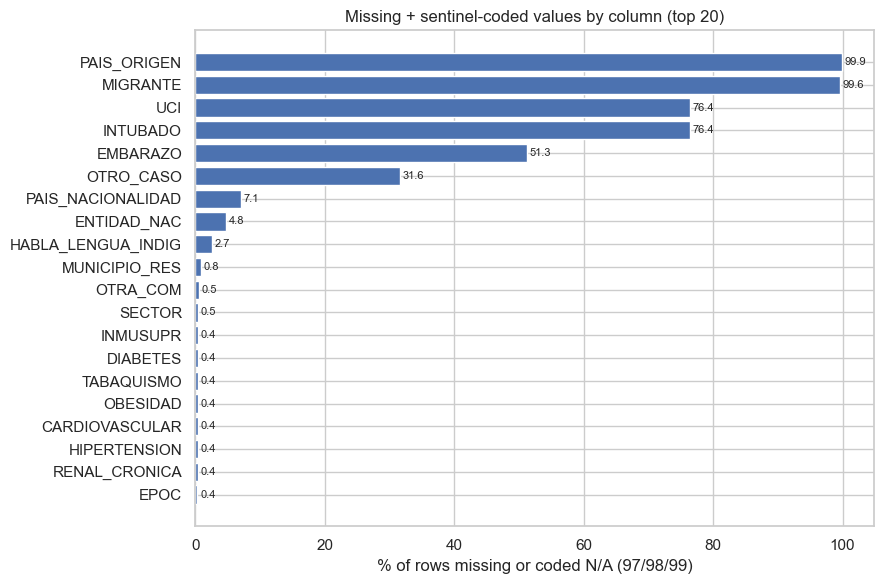

In [25]:
# ---------------------------------------------------------------------------
# 6c. PLOT 1 (data quality) — combined missing + sentinel rates
# ---------------------------------------------------------------------------
combined = (df.isna().mean() * 100).add(sent, fill_value=0).sort_values(ascending=False)
combined = combined[combined > 0].head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(combined.index[::-1], combined.values[::-1], color="#4C72B0")
ax.set_xlabel("% of rows missing or coded N/A (97/98/99)")
ax.set_title("Missing + sentinel-coded values by column (top 20)")
for i, v in enumerate(combined.values[::-1]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Candidate targets & class (im)balance

The three natural supervised targets are **hospitalization**, **death**, and **COVID positivity**. We inspect each one's distribution and compute the imbalance ratio, because accuracy is misleading on skewed targets — this directly motivates the metric choices in Section B.

In [26]:
# ---------------------------------------------------------------------------
# 7. Target distributions
# ---------------------------------------------------------------------------
def describe_target(name, series, positive_label="positive"):
    s = series.dropna()
    if s.empty:
        print(f"[{name}] not available."); return None
    counts = s.value_counts().sort_index()
    prev = s.mean()
    minority = min(prev, 1 - prev)
    print(f"[{name}] n={len(s):,}  "
          f"{positive_label} prevalence={prev:.3%}  "
          f"majority-class baseline accuracy={max(prev,1-prev):.3%}  "
          f"imbalance(minority share)={minority:.3%}")
    return counts

target_specs = [
    ("HOSPITALIZED", "hospitalized"),
    ("DIED", "died"),
    ("COVID_POS", "COVID-positive"),
]
available_targets = [(t, lab) for (t, lab) in target_specs if t in data.columns]
for t, lab in available_targets:
    describe_target(t, data[t], lab)

[HOSPITALIZED] n=263,007  hospitalized prevalence=23.638%  majority-class baseline accuracy=76.362%  imbalance(minority share)=23.638%
[DIED] n=263,007  died prevalence=1.727%  majority-class baseline accuracy=98.273%  imbalance(minority share)=1.727%
[COVID_POS] n=263,007  COVID-positive prevalence=100.000%  majority-class baseline accuracy=100.000%  imbalance(minority share)=0.000%


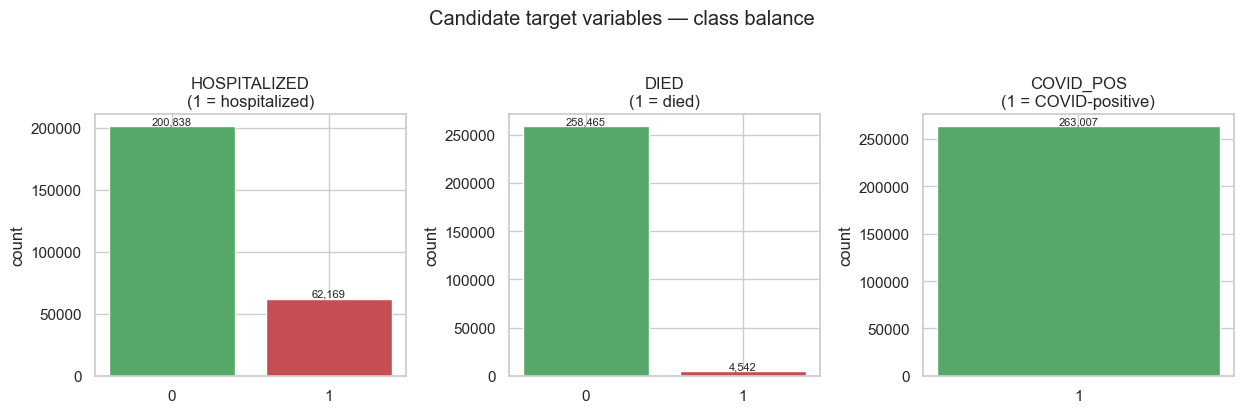

In [27]:
# ---------------------------------------------------------------------------
# 7b. PLOT 2 (target balance) — candidate target distributions
# ---------------------------------------------------------------------------
n = len(available_targets)
if n:
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (t, lab) in zip(axes, available_targets):
        vc = data[t].value_counts().sort_index()
        ax.bar([str(int(i)) for i in vc.index], vc.values,
               color=["#55A868", "#C44E52"][: len(vc)])
        ax.set_title(f"{t}\n(1 = {lab})")
        ax.set_ylabel("count")
        for i, v in enumerate(vc.values):
            ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    plt.suptitle("Candidate target variables — class balance", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print("No candidate targets resolved in this snapshot.")

## 8. Demographics — age and sex

Patient mix shapes everything downstream. We look at the age distribution and the sex split. Note these are the people who *entered the surveillance system*, not the general population (see §10).

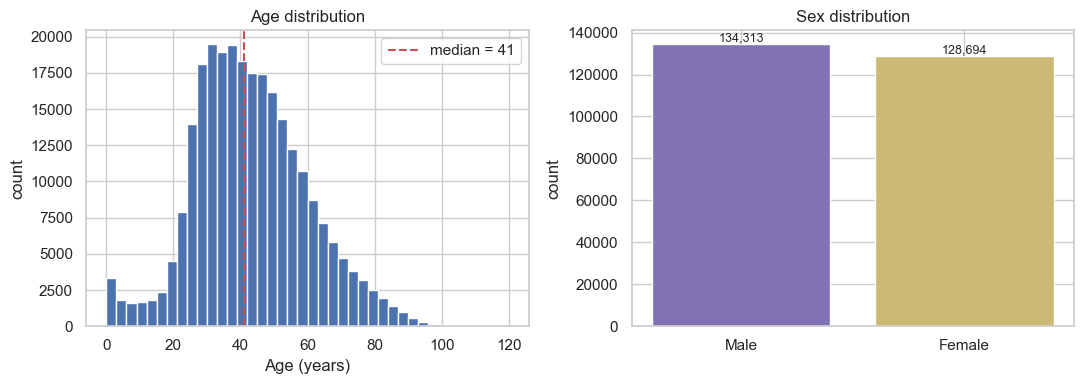

In [28]:
# ---------------------------------------------------------------------------
# 8. PLOT 3 (demographics) — age distribution + sex split
# ---------------------------------------------------------------------------
have_age = "AGE" in data.columns and data["AGE"].notna().any()
have_sex = "SEX_LABEL" in data.columns and data["SEX_LABEL"].notna().any()

ncols = int(have_age) + int(have_sex)
if ncols:
    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4))
    axes = np.atleast_1d(axes)
    i = 0
    if have_age:
        ax = axes[i]; i += 1
        ax.hist(data["AGE"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
        ax.axvline(data["AGE"].median(), color="#C44E52", ls="--",
                   label=f"median = {data['AGE'].median():.0f}")
        ax.set_xlabel("Age (years)"); ax.set_ylabel("count")
        ax.set_title("Age distribution"); ax.legend()
    if have_sex:
        ax = axes[i]
        vc = data["SEX_LABEL"].value_counts()
        ax.bar(vc.index, vc.values, color=["#8172B3", "#CCB974"][: len(vc)])
        ax.set_ylabel("count"); ax.set_title("Sex distribution")
        for j, v in enumerate(vc.values):
            ax.text(j, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("Neither AGE nor SEX_LABEL available.")

## 9. Feature ↔ outcome relationships (and a confounder)

Age is the dominant prognostic variable in COVID-19 and a classic **confounder**: it drives both comorbidity prevalence and outcomes. We show the death (or hospitalization) rate across age bands and across comorbidity burden — a clean, monotonic signal that any model will lean on, and a reminder to check whether apparent effects of comorbidities survive age adjustment.

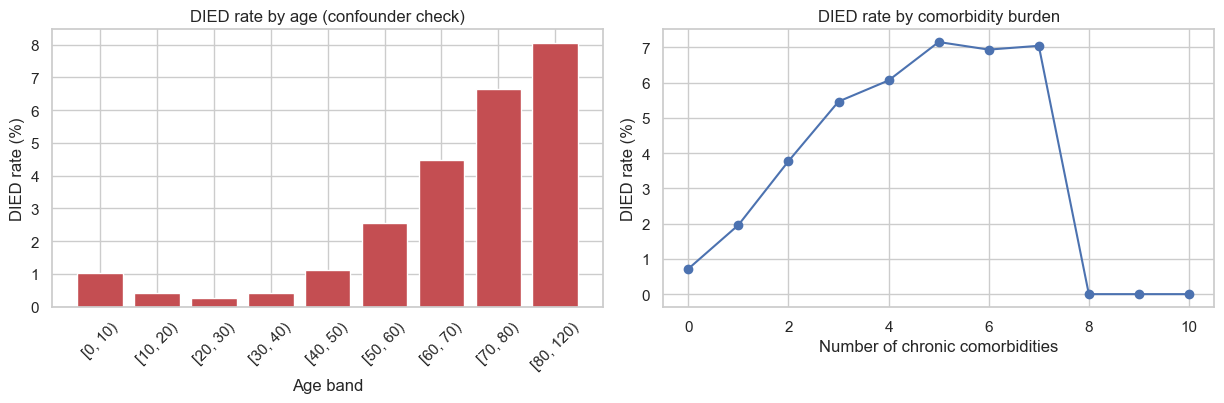

In [34]:
# ---------------------------------------------------------------------------
# 9. PLOT 4 (feature vs outcome / confounder)
# ---------------------------------------------------------------------------
# Pick the most "severe" available outcome to profile.
outcome = "DIED" if "DIED" in data.columns else ("HOSPITALIZED" if "HOSPITALIZED" in data.columns else None)

if outcome and have_age:
    tmp = data[["AGE", outcome]].dropna().copy()
    tmp["age_band"] = pd.cut(tmp["AGE"], bins=[0,10,20,30,40,50,60,70,80,120],
                             right=False)
    rate_by_age = tmp.groupby("age_band", observed=True)[outcome].mean() * 100

    has_ncom = "N_COMORBIDITIES" in data.columns and data["N_COMORBIDITIES"].notna().any()
    ncols = 1 + int(has_ncom)
    fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.2))
    axes = np.atleast_1d(axes)

    ax = axes[0]
    ax.bar([str(b) for b in rate_by_age.index], rate_by_age.values, color="#C44E52")
    ax.set_ylabel(f"{outcome} rate (%)")
    ax.set_xlabel("Age band")
    ax.set_title(f"{outcome} rate by age (confounder check)")
    ax.tick_params(axis="x", rotation=45)

    if has_ncom:
        ax = axes[1]
        t2 = data[["N_COMORBIDITIES", outcome]].dropna()
        rate_by_ncom = t2.groupby("N_COMORBIDITIES")[outcome].mean() * 100
        ax.plot(rate_by_ncom.index, rate_by_ncom.values, "o-", color="#4C72B0")
        ax.set_xlabel("Number of chronic comorbidities")
        ax.set_ylabel(f"{outcome} rate (%)")
        ax.set_title(f"{outcome} rate by comorbidity burden")
    plt.tight_layout(); plt.show()
else:
    print("Need AGE plus an outcome (DIED/HOSPITALIZED) for this plot.")

## 10. Sampling bias & leakage structure (the key data-criticism plot)

The surveillance design tests **100% of severe/SARI** patients but only **~10% of mild** patients, and essentially **no asymptomatic** people. So this dataset over-represents severe disease relative to the population — any prevalence you measure (hospitalization, death, even positivity) is a *property of the sampled, mostly-symptomatic population*, not of the general public.

This same design also explains why `INTUBED` and `ICU` are dangerous: they are recorded during/after admission. We demonstrate it directly — for outpatients these fields are almost entirely coded *not applicable (97)*, confirming they carry post-admission (outcome-time) information and **must not** be used to predict hospitalization at presentation.

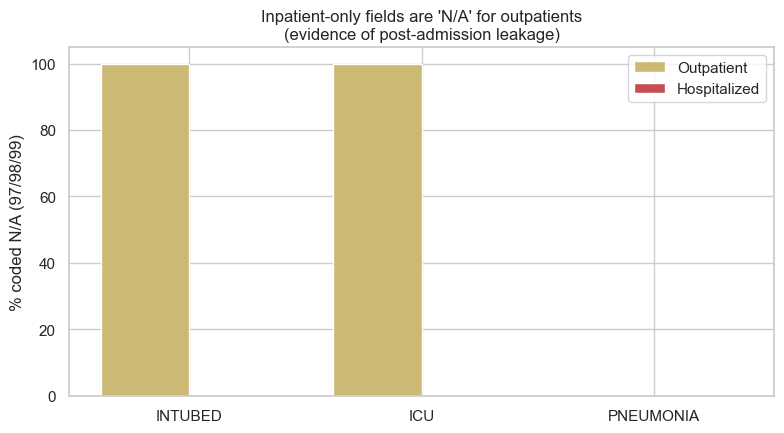

patient_type,Hospitalized,Outpatient
field,,
ICU,0.06,100.00
INTUBED,0.06,100.00
PNEUMONIA,0.00,0.01


In [30]:
# ---------------------------------------------------------------------------
# 10. PLOT 5 (sampling bias / leakage) — N/A rate of INTUBED & ICU by patient type
# ---------------------------------------------------------------------------
leak_keys = [k for k in ["intubed", "icu", "pneumonia"] if COL[k]]
if COL["patient_type"] and leak_keys:
    pt = pd.to_numeric(df[COL["patient_type"]], errors="coerce")
    pt_label = pt.map({1: "Outpatient", 2: "Hospitalized"})

    rows = []
    for k in leak_keys:
        raw = pd.to_numeric(df[COL[k]], errors="coerce")
        na_flag = raw.isin([97, 98, 99])
        for grp in ["Outpatient", "Hospitalized"]:
            m = pt_label == grp
            if m.any():
                rows.append({"field": k.upper(), "patient_type": grp,
                             "pct_not_applicable": na_flag[m].mean() * 100})
    biasdf = pd.DataFrame(rows)

    fields = biasdf["field"].unique()
    x = np.arange(len(fields)); w = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for j, grp in enumerate(["Outpatient", "Hospitalized"]):
        vals = [biasdf[(biasdf.field == f) & (biasdf.patient_type == grp)]["pct_not_applicable"].squeeze()
                if not biasdf[(biasdf.field == f) & (biasdf.patient_type == grp)].empty else 0
                for f in fields]
        ax.bar(x + (j - 0.5) * w, vals, w, label=grp,
               color=["#CCB974", "#C44E52"][j])
    ax.set_xticks(x); ax.set_xticklabels(fields)
    ax.set_ylabel("% coded N/A (97/98/99)")
    ax.set_title("Inpatient-only fields are 'N/A' for outpatients\n(evidence of post-admission leakage)")
    ax.legend()
    plt.tight_layout(); plt.show()
    display(biasdf.pivot(index="field", columns="patient_type", values="pct_not_applicable").round(2))
else:
    print("Need patient_type plus at least one of INTUBED/ICU/PNEUMONIA for this plot.")

## 11. Leakage audit table

A compact, defensible audit for the **hospitalization-at-presentation** task (the recommended primary task in §13). The rule of thumb: anything recorded *during or after* the hospital stay is unavailable at prediction time and must be excluded.

In [ ]:
# ---------------------------------------------------------------------------
# 11. Leakage audit (for "predict hospitalization at first presentation")
# ---------------------------------------------------------------------------
audit = [
    ("AGE",              "Yes", "Yes", "Known at presentation; strong baseline prognostic factor"),
    ("SEX",              "Yes", "Yes", "Known at presentation"),
    ("Chronic comorbidities (DIABETES, HYPERTENSION, OBESITY, COPD, ASTHMA, RENAL_CRONICA, CARDIOVASCULAR, IMMSUPR, TOBACCO)",
                          "Yes", "Yes", "Pre-existing conditions, reported at intake"),
    ("PREGNANCY",        "Yes", "Yes", "Known at presentation"),
    ("PNEUMONIA",        "At triage?", "Cautious", "May be an admission-time finding OR a discharge dx; justify or exclude"), # Consider removing and mention in report
    ("INTUBED",          "No",  "No",  "Recorded during admission; downstream of the outcome -> leakage"),
    ("ICU",              "No",  "No",  "Recorded during admission; downstream of the outcome -> leakage"),
    ("DATE_DIED / DIED", "No",  "No",  "Final outcome of the stay; pure leakage for hospitalization task"),
    ("CLASIFICACION_FINAL","Often later","Cautious","Lab result may arrive after admission; check timing vs prediction moment"),
]
audit_df = pd.DataFrame(audit, columns=["Variable", "Available at prediction time?",
                                        "Included?", "Reason"])
display(audit_df)

,Variable,Available at prediction time?,Included?,Reason
0,AGE,Yes,Yes,Known at presentation; strong baseline prognos...
1,SEX,Yes,Yes,Known at presentation
2,"Chronic comorbidities (DIABETES, HYPERTENSION,...",Yes,Yes,"Pre-existing conditions, reported at intake"
3,PREGNANCY,Yes,Yes,Known at presentation
4,PNEUMONIA,At triage?,Cautious,May be an admission-time finding OR a discharg...
5,INTUBED,No,No,Recorded during admission; downstream of the o...
6,ICU,No,No,Recorded during admission; downstream of the o...
7,DATE_DIED / DIED,No,No,Final outcome of the stay; pure leakage for ho...
8,CLASIFICACION_FINAL,Often later,Cautious,Lab result may arrive after admission; check t...


## 12. Fairness & representation reflection

A short but substantive check (required by the rubric). We look at who is in the data and where the model is therefore likely to be reliable — and where it is not.

- **Selection by severity.** Because testing was rationed by severity, mild and asymptomatic cases are largely absent. A model trained here learns to separate *severe-presenting* patients and may behave unpredictably on the milder population it would meet in real deployment.
- **Access to care.** Entry requires reaching a sentinel unit. People with poor healthcare access (rural, uninsured, indigenous-language speakers) are under-represented, so error rates may be systematically worse for them — yet they are exactly the groups a triage tool would most affect.
- **Demographic skew.** We quantify representation by sex and age band below; large imbalances flag subgroups where confidence intervals on performance will be wide.

In [32]:
# ---------------------------------------------------------------------------
# 12. Representation by sex and age band
# ---------------------------------------------------------------------------
if have_sex:
    print("Sex representation:")
    print((data["SEX_LABEL"].value_counts(normalize=True) * 100).round(2).to_string(), "\n")

if have_age:
    bands = pd.cut(data["AGE"], bins=[0,18,40,60,80,120], right=False)
    print("Age-band representation:")
    print((bands.value_counts(normalize=True).sort_index() * 100).round(2).to_string())

Sex representation:
SEX_LABEL
Male      51.07
Female    48.93 

Age-band representation:
AGE
[0, 18)       4.80
[18, 40)     41.24
[40, 60)     38.21
[60, 80)     13.35
[80, 120)     2.40


## 13. Recommended prediction tasks

Below are **three** supervised tasks supported by this dataset. Each is specified for the report: task type & target, leakage handling (with the features to exclude), and the relevance/storytelling angle plus how to frame the target and generalization populations. **Task 1 is the recommended primary choice** because its prediction moment (first presentation) is the cleanest fit for the dataset and makes the leakage story easy to defend.

---

### Task 1 — Predict hospitalization at first presentation *(recommended primary)*

**1. Task definition.** Binary **classification**. Target = `TIPO_PACIENTE` recoded to `HOSPITALIZED` (1 = hospitalized, 0 = outpatient). Prediction moment: the moment of first clinical presentation, using only information a clinician has then.

**2. Preventing leakage.** Safe *because the target is decided around admission*, so you simply forbid any post-admission field. **Must exclude:** `INTUBED`, `ICU` (recorded during the stay — §10 shows they are "N/A" for nearly all outpatients), `DATE_DIED`/`DIED` (final outcome). Treat `PNEUMONIA` with caution: include only if you argue it is an at-triage finding, otherwise drop it. Treat `CLASIFICACION_FINAL` as cautious — the lab result often arrives after admission. **Safe features:** `AGE`, `SEX`, chronic comorbidities, `PREGNANCY`.

**3. Argumentation & storytelling.** Directly relevant to **hospital resource and bed planning / triage** — a clinically intuitive, easy-to-justify framing. *Prediction population:* symptomatic patients presenting at a sentinel surveillance unit. *Generalization target:* future symptomatic presenters at similar Mexican units — explicitly **not** the general population, because mild/asymptomatic people are under-sampled (§10).

---

### Task 2 — Predict in-hospital mortality among admitted patients

**1. Task definition.** Binary **classification**. Target = `DIED` (from the `FECHA_DEF` placeholder). Restrict the cohort to hospitalized patients (`HOSPITALIZED == 1`) so the question is "given admission, who dies?"

**2. Preventing leakage.** The prediction moment is *at/just after admission*, so end-of-stay information is forbidden. **Must exclude:** `DATE_DIED` itself (it defines the label), and anything recorded at discharge. `INTUBED`/`ICU` are borderline — if your prediction moment is admission they are leakage and should be excluded; only include them if you explicitly move the prediction moment to "after ICU triage" and say so. **Safe features:** `AGE`, `SEX`, comorbidities, `PNEUMONIA` (defensible as an admission finding here), `PREGNANCY`.

**3. Argumentation & storytelling.** Relevant to **prognosis and ICU/clinical prioritisation**. Strong class imbalance makes it a good vehicle for the metric discussion (PR-AUC, recall, calibration) the rubric rewards. *Prediction population:* hospitalized surveillance patients. *Generalization target:* future admitted patients at comparable units; note the survivorship/selection effects from who gets admitted in the first place.

---

### Task 3 — Predict laboratory-confirmed COVID-19 positivity

**1. Task definition.** Binary **classification**. Target = `COVID_POS` (`CLASIFICACION_FINAL` ∈ {1,2,3}, or `RESULTADO == 1`). Goal: from presentation-time demographics/symptoms/comorbidities, estimate the probability the test comes back positive.

**2. Preventing leakage.** Exclude everything that resolves *after* the test/stay: `INTUBED`, `ICU`, `DATE_DIED`. The subtle leak here is **temporal**: the label arrives later, so be sure every feature is a presentation-time field. **Safe features:** `AGE`, `SEX`, comorbidities, contact history (`OTRO_CASO`) if present, `PNEUMONIA` only if argued as a triage finding.

**3. Argumentation & storytelling.** Relevant to **test-targeting / pre-test probability** when testing capacity is scarce — which is literally the rationing situation that produced this dataset, making the framing self-consistent. *Be explicit about the heaviest bias:* because severe cases were tested far more than mild ones, "positivity among the tested" ≠ "positivity in the population." *Prediction population:* tested patients at sentinel units. *Generalization target:* future tested patients under a similar testing policy — generalisation to the untested population is not supported.

---

### Suggested next steps (Sections B & C)
1. Freeze a train/test split now and **save the indices** before any model selection (reproducibility checklist).
2. Build an `sklearn` `Pipeline` (imputation → encoding → scaling → model) so preprocessing is *learned only on training folds*.
3. Compare a trivial baseline (majority class / prevalence) against logistic regression + two other families (e.g., random forest, gradient boosting), keeping the total fitted models ≲ 200.
4. Report a primary metric justified by the imbalance you measured in §7 (PR-AUC / recall are usually more honest than accuracy here), then do the error analysis required in Section C.